In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [12]:
# Cargamos el dataset de Iris-Setosa
x = pd.read_csv('iris.csv')
print(x.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [13]:
#variables predictoras 
x1 = x.iloc[:, :-1].values


# variable de salida
y1 = x.iloc[:, -1].values

print(x1.shape)
print(y1.shape)


(150, 5)
(150,)


In [14]:
# Centramos los datos
D = x1 - np.mean(x1, axis = 0)
print(type(D))
print(D.shape)

<class 'numpy.ndarray'>
(150, 5)


In [15]:
# Compute the cov matrix 

S = (1/ (len(D)-1)) * np.dot(D.T, D)  
print(S.shape)


(5, 5)


In [16]:
# calculamos los autovalores y autovectores

eigenvalues, eigenvectors = np.linalg.eig(S)
print(eigenvalues)
print(eigenvectors) #los vectores propios son las columnas de la matriz

[1.89078098e+03 9.73286632e-01 2.22994729e-01 6.92908368e-02
 2.27360616e-02]
[[-0.99913157 -0.04071433 -0.00712756 -0.00497451 -0.00170534]
 [-0.01365776  0.49432522 -0.55014214 -0.6110462   0.28181947]
 [ 0.00396685 -0.01499187 -0.77852879  0.54687614 -0.30753685]
 [-0.0358369   0.82236709  0.29611241  0.19490229 -0.44357483]
 [-0.01579744  0.2783389   0.05918769  0.53808678  0.79324481]]


In [17]:
# ordenamos los valores propios y los vectores propios
indices = np.argsort(eigenvalues)[::-1] # forma descendente
eigenval_sorted = eigenvalues[indices] #reordenamos los valores propios de mayor a menor
eigenvect_sorted = eigenvectors[:, indices] #reordenamos los vectores propios de acuerdo a los valores propios
print(eigenval_sorted)
print(eigenvect_sorted)


[1.89078098e+03 9.73286632e-01 2.22994729e-01 6.92908368e-02
 2.27360616e-02]
[[-0.99913157 -0.04071433 -0.00712756 -0.00497451 -0.00170534]
 [-0.01365776  0.49432522 -0.55014214 -0.6110462   0.28181947]
 [ 0.00396685 -0.01499187 -0.77852879  0.54687614 -0.30753685]
 [-0.0358369   0.82236709  0.29611241  0.19490229 -0.44357483]
 [-0.01579744  0.2783389   0.05918769  0.53808678  0.79324481]]


In [18]:
# Seleccionamos los dos primeros vectores propios
k = 2
W = eigenvect_sorted[:,:k:1]
print(W)

[[-0.99913157 -0.04071433]
 [-0.01365776  0.49432522]
 [ 0.00396685 -0.01499187]
 [-0.0358369   0.82236709]
 [-0.01579744  0.2783389 ]]


In [19]:
#proyectamos los datos originales en el nuevo espacio
Y = np.dot(D,W)
print(Y.shape)
print(Y)

(150, 2)
[[ 7.45475269e+01  4.41425501e-01]
 [ 7.35491434e+01  3.09342060e-01]
 [ 7.25571205e+01  8.45275987e-02]
 [ 7.15517906e+01  1.60353347e-01]
 [ 7.05527631e+01  2.27636455e-01]
 [ 6.95354479e+01  6.82532551e-01]
 [ 6.85575899e+01 -2.06900363e-02]
 [ 6.75509913e+01  1.90728535e-01]
 [ 6.65616547e+01 -2.21321702e-01]
 [ 6.55544836e+01  3.65310173e-02]
 [ 6.45493236e+01  2.61818058e-01]
 [ 6.35536129e+01  1.12428635e-02]
 [ 6.25616417e+01 -2.15782028e-01]
 [ 6.15800901e+01 -7.50369097e-01]
 [ 6.05592753e+01  4.54831204e-02]
 [ 5.95491857e+01  2.51717420e-01]
 [ 5.85593354e+01 -9.42719598e-02]
 [ 5.75607105e+01 -2.22884291e-01]
 [ 5.65438233e+01  2.75209069e-01]
 [ 5.55600537e+01 -2.26573813e-01]
 [ 5.45496505e+01  2.36456947e-02]
 [ 5.35598142e+01 -2.78669404e-01]
 [ 5.25881927e+01 -1.03189848e+00]
 [ 5.15512172e+01 -1.61794017e-01]
 [ 5.05541515e+01 -2.71333356e-01]
 [ 4.95614527e+01 -4.53896023e-01]
 [ 4.85607484e+01 -4.44939327e-01]
 [ 4.75660251e+01 -5.26192293e-01]
 [ 4.657008


Tiempo total de ejecución: 0.0076 segundos

Precisión del clasificador k-NN (k=2) sobre el conjunto de prueba: 100.00%


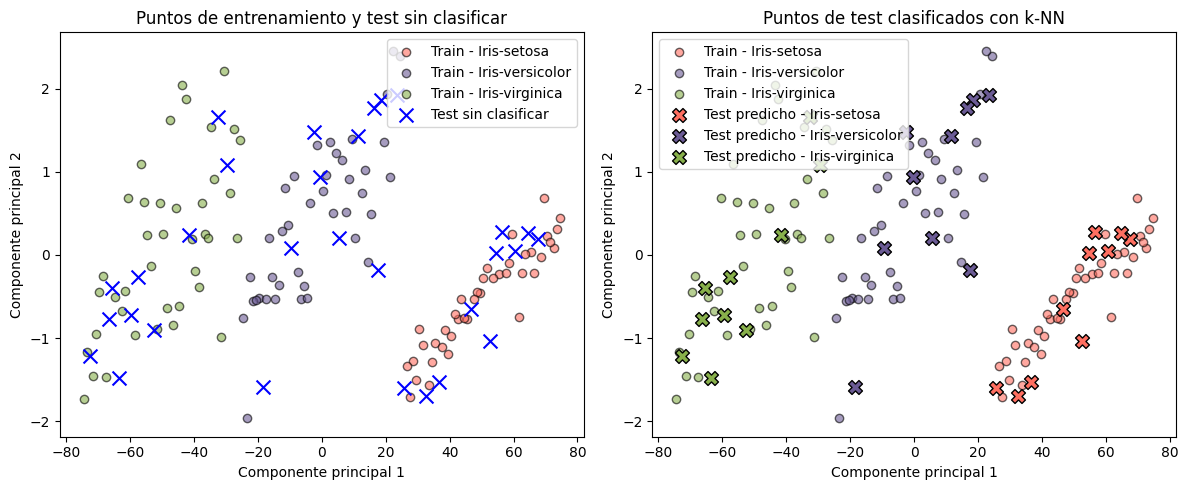

In [20]:
# Función para calcular distancias euclidianas
def calcular_distancias(punto, conjunto_puntos):
    return np.linalg.norm(conjunto_puntos - punto, axis=1)

# Dividir en 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    Y, y1, test_size=0.2, random_state=42, stratify=y1
)

import time

# Graficamos los Puntos de test antes de clasificar
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
colores = {
    'Iris-setosa': '#FF6F61',       
    'Iris-versicolor': '#6B5B95',   
    'Iris-virginica': '#88B04B'     
}

# Entrenamiento coloreado
for especie in np.unique(y_train):
    idx = y_train == especie
    plt.scatter(X_train[idx, 0], X_train[idx, 1], label=f'Train - {especie}',
                alpha=0.6, edgecolors='k', color=colores[especie])

# Test sin clasificar en azul
plt.scatter(X_test[:, 0], X_test[:, 1], label='Test sin clasificar',
            color='blue', marker='x', s=100)

plt.title('Puntos de entrenamiento y test sin clasificar')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.legend()

# Clasificar puntos de test usando k-NN manual
inicio = time.time()
predicciones = []

for punto_test in X_test:
    distancias = calcular_distancias(punto_test, X_train)
    indices_vecinos = distancias.argsort()[:k]
    vecinos = y_train[indices_vecinos]
    predicha = pd.Series(vecinos).value_counts().idxmax()
    predicciones.append(predicha)

fin = time.time()
print(f"\nTiempo total de ejecución: {fin - inicio:.4f} segundos")

# Calcular precisión
precision = accuracy_score(y_test, predicciones)
print(f"\nPrecisión del clasificador k-NN (k={k}) sobre el conjunto de prueba: {precision:.2%}")

# Gráficar los  Puntos de test clasificados
plt.subplot(1, 2, 2)

# Entrenamiento
for especie in np.unique(y_train):
    idx = y_train == especie
    plt.scatter(X_train[idx, 0], X_train[idx, 1], label=f'Train - {especie}',
                alpha=0.6, edgecolors='k', color=colores[especie])

# Test clasificados por predicción
for especie in np.unique(predicciones):
    idx = np.array(predicciones) == especie
    plt.scatter(X_test[idx, 0], X_test[idx, 1],
                label=f'Test predicho - {especie}',
                marker='X', s=100, edgecolors='k', color=colores[especie])

plt.title('Puntos de test clasificados con k-NN')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.legend()

plt.tight_layout()
plt.show()

